In [7]:
import torch as th
import numpy as np
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
import scipy.io as sio
import time
import os
import pandas as pd
from tqdm import tqdm
import seaborn as sns

import sys
sys.path.append('..')

import soft_tex.common.aux_plot
from soft_tex.common.aux_data import get_dataset_dict, exponential_moving_average
from soft_tex.model.networks import SoftSensingLSTM

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [ ]:
def exponential_moving_average(x, alpha):
    assert(type(alpha) == float or len(alpha) == x.shape[1]) 
    assert(np.all(alpha < 1))
    assert(np.all(alpha >  0))
    
    s = np.zeros_like(x)
    
    s[0,:] = x[0,:]
    for t in range(1, len(x), 1):
        s[t,:] = alpha * x[t,:] + (1 - alpha) * s[t-1,:]

    return s


In [ ]:
data_dir_path = '../data/SoftTex/'
dataset_names = ['dataset_res_sens_pos_1.mat', 'dataset_res_sens_pos_2.mat', 'dataset_res_sens_pos_3.mat']

dataset_dict = get_dataset_dict(data_dir_path=data_dir_path, dataset_names=dataset_names)

# Concatenate pressure dataset
pressure_dataset_names = ['dataset_act_sens_pos_1.mat', 
                          'dataset_act_sens_pos_2.mat', 
                          'dataset_act_sens_pos_3.mat']

for dataset_name, pressure_dataset_name in zip(dataset_names, pressure_dataset_names):
    dataset = sio.loadmat(data_dir_path + pressure_dataset_name)['Dataset']
    pressures = dataset[:, [0,1,2]]

    dataset_dict[dataset_name]['pressure'] = pressures

In [ ]:
# 312 in paper
TR_idx = 3
VL_idx = 1
TS_idx = 2

set_index_to_name_dict = {TR_idx: 'Training set',
                          VL_idx: 'Validation set',
                          TS_idx: 'Test set'}

print(set_index_to_name_dict)


name_to_violin_color = {'Training set' : sns.palettes.SEABORN_PALETTES['pastel6'][1],
                        'Validation set': sns.palettes.SEABORN_PALETTES['pastel6'][0],
                        'Test set': sns.palettes.SEABORN_PALETTES['pastel6'][2]}

name_to_curve_color = {'Training set': sns.palettes.SEABORN_PALETTES['dark'][2],
                       'Validation set': sns.palettes.SEABORN_PALETTES['dark'][0],
                       'Test set': sns.palettes.SEABORN_PALETTES['dark'][1]
                       }
 
print(name_to_violin_color)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# datasets
tr_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['pressure']
tr_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['sensor_resistance']
tr_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TR_idx]['tip_position']

vl_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['pressure']
vl_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['sensor_resistance']
vl_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % VL_idx]['tip_position']

ts_pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['pressure']
ts_sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['sensor_resistance']
ts_tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['tip_position']

X_tr_series = np.concatenate((tr_pressure, tr_sensor), axis=1)
X_vl_series = np.concatenate((vl_pressure, vl_sensor), axis=1)
X_ts_series = np.concatenate((ts_pressure, ts_sensor), axis=1)
Y_tr_series = tr_tip_position
Y_vl_series = vl_tip_position
Y_ts_series = ts_tip_position

# Create development set, create scalers and fit the scalers
# Fit the scalers on the original data;
X_development = np.concatenate((X_tr_series, X_vl_series, X_ts_series))
Y_development = np.concatenate((Y_tr_series, Y_vl_series, Y_ts_series))

observation_scaler = StandardScaler().fit(X_development) #MinMaxScaler(feature_range=(-1,1)) #StandardScaler()
output_scaler = StandardScaler().fit(Y_development) #MinMaxScaler(feature_range=(-1,1)) #StandardScaler() #MinMaxScaler(feature_range=(0,1))

In [ ]:
model_path = '../models/trained_model_3.9'
#model_path = '../models/trained_model_date_2024.06.07_h_11.08'
#model_path = '../models/trained_model_date_2024.06.07_h_19.11'
model_path = '../models/trained_model_date_2024.06.07_h_23.38'
model_path = '../models/trained_model_date_2024.06.09_h_20.31' # 3.4
model_path = '../models/trained_model_date_2024.06.09_h_23.09'
model_path = '../models/trained_model_date_2024.06.09_h_23.57'
model_path = '../models/trained_model_date_2024.06.10_h_10.37'

# curriculum
model_path = '../models/trained_model_date_2024.06.10_h_12.00' # 3.4 curriculum

# no curriculum
#model_path = '../models/trained_model_date_2024.06.12_h_15.23' # no curriculum, seq_len = 20 fixed
#model_path = '../models/trained_model_date_2024.06.12_h_17.33' # no curriculum, seq_len = 30 fixed
#model_path = '../models/trained_model_date_2024.06.12_h_18.08' # no curriculum, seq_len = 40 fixed
#model_path = '../models/trained_model_date_2024.06.12_h_16.28' # no curriculum, seq_len = 60 fixed

net = th.load(model_path)
net.eval()

print(net)

In [ ]:
results_dict = {}

for dataset_name in dataset_dict:
    pressure = dataset_dict[dataset_name]['pressure']
    sensor = dataset_dict[dataset_name]['sensor_resistance']
    tip_position = dataset_dict[dataset_name]['tip_position']

    # Apply EMA on the original data, them scale the smoothed data.
    X_series = np.concatenate((pressure, sensor), axis=1)
    X_series = exponential_moving_average(X_series, alpha=np.array([0.6, 0.6, 0.6, 0.4, 0.4, 0.4]))

    Y_series = tip_position

    # scale dateset and convert to Tensors
    X_series = th.Tensor(observation_scaler.transform(X_series)).unsqueeze(1)
    Y_series = th.Tensor(output_scaler.transform(Y_series)).unsqueeze(1)

    # reset network states and predict
    net.reset_states()
    Y_hats = net.predict(X_series)

    # inverse transform to original scale
    real_pos_tips = output_scaler.inverse_transform(Y_series.squeeze())
    pred_pos_tips = output_scaler.inverse_transform(Y_hats.squeeze())
    
    errors = np.linalg.norm(real_pos_tips - pred_pos_tips, axis=1)

    # save results
    results_dict[dataset_name] = dict(real_pos_tips=real_pos_tips,
                                      pred_pos_tips=pred_pos_tips,
                                      errors=errors)

In [ ]:
errors_1 = results_dict['dataset_res_sens_pos_1.mat']['errors']
errors_2 = results_dict['dataset_res_sens_pos_2.mat']['errors']
errors_3 = results_dict['dataset_res_sens_pos_3.mat']['errors']

all_errors = [errors_1, errors_2, errors_3]

for i, errors in enumerate(all_errors):
    print(i + 1, set_index_to_name_dict[i+1])
    L = 60 # mm

    print('mean: %.1f mm +- %.1f mm ' \
          '(%.1f%%L +- %.1f%%L)' % (np.mean(errors), np.std(errors), np.mean(errors) / L * 100, np.std(errors) / L * 100))
    #print('max: %.1f mm (%.1f%%L)' % (np.max(errors), np.max(errors) / L * 100))

print('-----------')
print("Overall (mm): %.1f +- %.1f" % (np.mean(np.concatenate(all_errors)), np.std(np.concatenate(all_errors))))
print("Overall (%%L): %.1f +- %.1f" % (np.mean(np.concatenate(all_errors)) / L * 100, np.std(np.concatenate(all_errors)) / L * 100))

In [ ]:
fig = plt.figure(figsize=(6,4), dpi=600)

ax = sns.violinplot(data=all_errors, 
                    native_scale=True, orient='h', 
                    inner='box',
                    palette=[
                        name_to_violin_color[set_index_to_name_dict[1]],
                        name_to_violin_color[set_index_to_name_dict[2]],
                        name_to_violin_color[set_index_to_name_dict[3]],
                    ], # sns.palettes.SEABORN_PALETTES.keys()
                   inner_kws=dict(box_width=15,
                                  whis_width=2, color=".3", ))

# annotations (dal basso all'alto)
plt.annotate(text=set_index_to_name_dict[TR_idx], xy=(8, TR_idx - 1 + 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][2]) # 2
plt.annotate(text=set_index_to_name_dict[VL_idx], xy=(8, VL_idx - 1 + 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][0]) # 1
plt.annotate(text=set_index_to_name_dict[TS_idx], xy=(8, TS_idx - 1 + 0.2), color=sns.palettes.SEABORN_PALETTES['dark'][1]) # 0

plt.xlabel('Tip Error, $\mathcal{E}$ (mm)')
plt.yticks([0,1,2], [1, 2, 3])
plt.grid()
plt.tight_layout()
plt.savefig(fname='../figures/error_distributions.pdf', bbox_inches='tight')
plt.savefig(fname='../figures/error_distributions.png', bbox_inches='tight')
plt.savefig(fname='../figures/error_distributions.svg', bbox_inches='tight')
plt.show()

In [ ]:
sampling_frequency = 50 # Hz
n_samples_1 = errors_1.shape[0]
n_samples_2 = errors_2.shape[0]
n_samples_3 = errors_3.shape[0]

total_time_1 = n_samples_1 / sampling_frequency
total_time_2 = n_samples_2 / sampling_frequency
total_time_3 = n_samples_3 / sampling_frequency

t_1 = np.linspace(0, total_time_1, num=n_samples_1)
t_2 = np.linspace(0, total_time_2, num=n_samples_2)
t_3 = np.linspace(0, total_time_3, num=n_samples_3)

fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1, sharex=True, dpi=600)
ax1.plot(t_1/t_1[-1], errors_1, color=name_to_curve_color[set_index_to_name_dict[1]], label=set_index_to_name_dict[1])
ax2.plot(t_2/t_2[-1], errors_2, color=name_to_curve_color[set_index_to_name_dict[2]], label=set_index_to_name_dict[2])
ax3.plot(t_3/t_3[-1], errors_3, color=name_to_curve_color[set_index_to_name_dict[3]], label=set_index_to_name_dict[3])

ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax1.grid()
ax2.grid()
ax3.grid()

plt.xlabel('Time, $t/T$')
ax2.set_ylabel('Tip Error, $\mathcal{E}$ (mm)')
plt.tight_layout()
plt.savefig(fname='../figures/error_time_series.pdf', bbox_inches='tight')
plt.savefig(fname='../figures/error_time_series.png', bbox_inches='tight')
plt.savefig(fname='../figures/error_time_series.svg', bbox_inches='tight')
plt.show()

In [ ]:
real_pos_tips = results_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['real_pos_tips']
pred_pos_tips = results_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['pred_pos_tips']

n_samples = real_pos_tips.shape[0]
total_time = n_samples / sampling_frequency
t = np.linspace(0, total_time, num=n_samples)

# positions
fig, (ax1, ax2, ax3) =  plt.subplots(figsize=(8,6), nrows=3, ncols=1, sharex=True, dpi=600)
ax1.plot(t, real_pos_tips[:, 0], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2], label='Experiment')
ax1.plot(t, pred_pos_tips[:, 0], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0], label='Prediction')

ax2.plot(t, real_pos_tips[:, 1], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2])
ax2.plot(t, pred_pos_tips[:, 1], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0])

ax3.plot(t, real_pos_tips[:, 2], linewidth=2, color=sns.palettes.SEABORN_PALETTES['bright'][2],)
ax3.plot(t, pred_pos_tips[:, 2], linewidth=2, linestyle=':', color=sns.palettes.SEABORN_PALETTES['bright'][0])

# labels
ax1.set_ylabel('$x$ (mm)'); ax2.set_ylabel('$y$ (mm)'); ax3.set_ylabel('$z$ (mm)')
# grids
ax1.grid(); ax2.grid(); ax3.grid()
plt.xlabel('Time, $t$ (s)')
ax1.legend(loc='upper right', ncols=1)
plt.tight_layout()
plt.savefig(fname='../figures/prediction_vs_robot.pdf', bbox_inches='tight')
plt.savefig(fname='../figures/prediction_vs_robot.png', bbox_inches='tight')
plt.savefig(fname='../figures/prediction_vs_robot.svg', bbox_inches='tight')
plt.show()

## Evaluate curriculum

In [ ]:
dataset_name = 'dataset_res_sens_pos_%d.mat' % TS_idx

pressure = dataset_dict[dataset_name]['pressure']
sensor = dataset_dict[dataset_name]['sensor_resistance']
tip_position = dataset_dict[dataset_name]['tip_position']

# Apply EMA on the original data, them scale the smoothed data.
X_series = np.concatenate((pressure, sensor), axis=1)
X_series = exponential_moving_average(X_series, alpha=np.array([0.6, 0.6, 0.6, 0.4, 0.4, 0.4]))

Y_series = tip_position

# scale dateset and convert to Tensors
X_series = th.Tensor(observation_scaler.transform(X_series)).unsqueeze(1)
Y_series = th.Tensor(output_scaler.transform(Y_series)).unsqueeze(1)

In [ ]:
model_paths = ['../models/trained_model_date_2024.06.10_h_12.00', # 3.4 curriculum
               '../models/trained_model_date_2024.06.12_h_15.23', # no curriculum, seq_len = 20 fixed
               '../models/trained_model_date_2024.06.12_h_17.33', # no curriculum, seq_len = 30 fixed
               '../models/trained_model_date_2024.06.12_h_18.08', # no curriculum, seq_len = 40 fixed
               '../models/trained_model_date_2024.06.12_h_16.28' # no curriculum, seq_len = 60 fixed
]

curriculum_results_dict = {}

In [ ]:
for model_path in tqdm(model_paths):
    net = th.load(model_path)
    net.eval()

    # reset network states and predict
    net.reset_states()
    Y_hats = net.predict(X_series)

    # inverse transform to original scale
    real_pos_tips = output_scaler.inverse_transform(Y_series.squeeze())
    pred_pos_tips = output_scaler.inverse_transform(Y_hats.squeeze())
    
    errors = np.linalg.norm(real_pos_tips - pred_pos_tips, axis=1)

    curriculum_results_dict[model_path] = errors    

In [ ]:
all_curriculum_errors = [err for err in curriculum_results_dict.values()]

plt.boxplot(all_curriculum_errors)
plt.show()
np.mean(all_curriculum_errors, axis=1)

In [ ]:
import scipy

data1 = np.random.normal(0.01, 1.2, size=2000)
data2 = np.random.normal(0.10, 1.2, size=2000)

# greater: The null hypothesis is that F(x) <= G(x) for all x; 
# the alternative is that F(x) > G(x) for at least one x. 
scipy.stats.ks_2samp(data1, data2, alternative='greater')

In [ ]:
#fig = plt.figure()
#ax = fig.add_subplot(projection='3d')

#ax.plot(tip_position[:,0], tip_position[:,1], tip_position[:,2])
#plt.show()

In [ ]:
X_series = np.concatenate((pressure, sensor), axis=1)
X_series = exponential_moving_average(X_series, alpha=np.array([0.6, 0.6, 0.6, 0.4, 0.4, 0.4]))

Y_series = tip_position

# scale dateset and convert to Tensors
X_series = th.Tensor(observation_scaler.transform(X_series)).unsqueeze(1)
Y_series = th.Tensor(output_scaler.transform(Y_series)).unsqueeze(1)

# reset network states and predict
net.eval()

execution_times = []
for i in range(3):
    net.reset_states()
    tic = time.time()
    Y_hats = net.predict(X_series)
    toc = time.time()
    execution_times.append(toc - tic)

mean_execution_time = np.mean(execution_times)
mean_prediction_time = mean_execution_time / pressures.shape[0]
mean_frequency = 1.0 / mean_prediction_time 

print("mean execution time: %.4f" % mean_execution_time)
print("mean prediction time: %.4f" % mean_prediction_time)
print("mean frequency: %.4f" % mean_frequency)

In [ ]:
dataset_duration = pressures.shape[0] / 50  # 50 Hz

In [ ]:
param_counter = np.sum([th.prod(th.tensor(params.shape)) for params in net.parameters()])

print("SoftText network number of parameters:", param_counter)

In [ ]:
import torch as th
import numpy as np

lstm_single = th.nn.LSTM(input_size=3, hidden_size=16)
lstm_double = th.nn.LSTM(input_size=6, hidden_size=16)

param_counter_single = np.sum([th.prod(th.tensor(params.shape)) for params in lstm_single.parameters()])
param_counter_double = np.sum([th.prod(th.tensor(params.shape)) for params in lstm_double.parameters()])

print('#parameters for single-modality LSTM:', param_counter_single)
print('#parametets for the two single-modality LSTM:', param_counter_single * 2)
print('#parameters for the monolitc LSTM:', param_counter_double)

reduction = (param_counter_double - param_counter_single) / param_counter_double * 100
print('Reduction of parameters for the single LSTM: %.1f%%' % reduction)

In [ ]:
# ablation
pressure = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['pressure']
sensor = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['sensor_resistance']
tip_position = dataset_dict['dataset_res_sens_pos_%d.mat' % TS_idx]['tip_position']

# 
X_series_ablation = np.concatenate((pressure, sensor), axis=1)
#X_series_ablation_p1[:, 0] = 0.0
#X_series_ablation = np.concatenate((np.zeros_like(pressure), sensor), axis=1)

#X_series_ablation_1 = np.concatenate((np.ones_like(pressure) * observation_scaler.mean_[:3], sensor), axis=1)
#X_series_ablation = np.concatenate((pressure, np.ones_like(sensor) * np.min(sensor)), axis=1)
#X_series_ablation = np.concatenate((pressure, np.ones_like(sensor) * observation_scaler.mean_[3:]), axis=1)
Y_series = tip_position

X_series_ablation = exponential_moving_average(X_series_ablation, alpha=np.array([0.6, 0.6, 0.6, 0.4, 0.4, 0.4]))

X_series_ablation = th.tensor(observation_scaler.transform(X_series_ablation), dtype=th.float32).unsqueeze(1)
Y_series_ablation = th.tensor(output_scaler.transform(Y_series), dtype=th.float32).unsqueeze(1)

net.eval()
net.reset_states()

Y_hats = net.predict(X_series_ablation)

real_pos_tips = output_scaler.inverse_transform(Y_series.squeeze())
pred_pos_tips = output_scaler.inverse_transform(Y_hats.squeeze())
    
errors = np.linalg.norm(real_pos_tips - pred_pos_tips, axis=1)


In [ ]:
np.mean(errors)

In [ ]:
observation_scaler.mean_.shape

### Check model selection (DELETE, USE THE DEDICATED NOTEBOOK)

In [9]:
results_path = '../trainings/model_selection.pth'

ms_results_dict  = th.load(results_path)

/tmp/ipykernel_11985/2333748953.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ms_results_dict  = th.load(results_path)


In [10]:
units = list(ms_results_dict['ParallelSoftSensingGRU'].keys())

gru_inference_times = [ms_results_dict['ParallelSoftSensingGRU'][unit]['inference_time']['mean'] for unit in units]
gru_parameters_count = [ms_results_dict['ParallelSoftSensingGRU'][unit]['parameters_count'] for unit in units]

lstm_inference_times = [ms_results_dict['ParallelSoftSensingLSTM'][unit]['inference_time']['mean'] for unit in units]
lstm_parameters_count = [ms_results_dict['ParallelSoftSensingLSTM'][unit]['parameters_count'] for unit in units]

In [11]:
max_param_count = np.max(np.concatenate((gru_parameters_count, lstm_parameters_count)))

gru_norm_parameters_count = np.array(gru_parameters_count) / max_param_count
lstm_norm_parameters_count = np.array(lstm_parameters_count) / max_param_count
gru_norm_parameters_count, lstm_norm_parameters_count

(array([0.24011956, 0.77681833]), array([0.3091996, 1.       ]))

In [16]:
def get_model_performance(selection_dict):
    gru_performance_dict = {}

    for unit in units:
        histories = selection_dict[unit]['histories']

        last_tr_losses = [history['training_losses'][-1] for history in histories]
        last_vl_losses = [history['validation_losses'][-1] for history in histories]
        
        gru_performance_dict[unit] = {}
        gru_performance_dict[unit]['mean_tr_loss'] = np.mean(last_tr_losses)
        gru_performance_dict[unit]['std_tr_loss'] = np.std(last_tr_losses)
        gru_performance_dict[unit]['mean_vl_loss'] = np.mean(last_vl_losses)
        gru_performance_dict[unit]['std_vl_loss'] = np.std(last_vl_losses)

    return gru_performance_dict

gru_performance_dict = get_model_performance(ms_results_dict['ParallelSoftSensingGRU'])
lstm_performance_dict = get_model_performance(ms_results_dict['ParallelSoftSensingLSTM'])

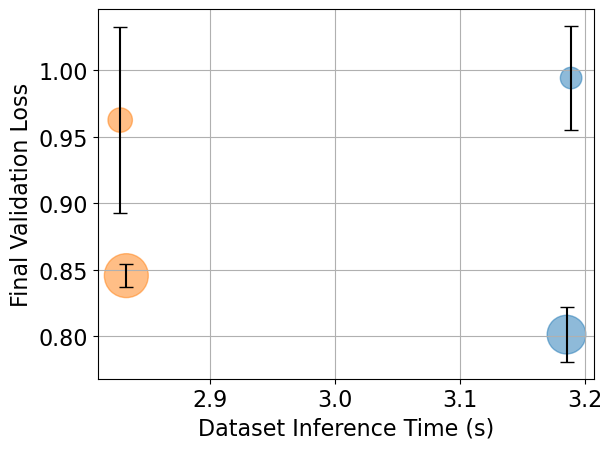

In [17]:
gru_vl_losses = np.array([gru_performance_dict[unit]['mean_vl_loss'] for unit in units])
gru_vl_std_losses = np.array([gru_performance_dict[unit]['std_vl_loss'] for unit in units])
lstm_vl_losses = np.array([lstm_performance_dict[unit]['mean_vl_loss'] for unit in units])
lstm_vl_std_losses = np.array([lstm_performance_dict[unit]['std_vl_loss'] for unit in units])

plt.scatter(x=gru_inference_times, y=gru_vl_losses, s=1e3*gru_norm_parameters_count, alpha=0.5)
plt.scatter(x=lstm_inference_times, y=lstm_vl_losses, s=1e3*lstm_norm_parameters_count, alpha=0.5)

# plot std as error line
plt.errorbar(x=gru_inference_times, y=gru_vl_losses, yerr=gru_vl_std_losses, linestyle='', c='black', barsabove=True, capsize=5)
plt.errorbar(x=lstm_inference_times, y=lstm_vl_losses, yerr=lstm_vl_std_losses, linestyle='', c='black', barsabove=True, capsize=5)

#plt.xscale('log')
#plt.yscale('log')
plt.ylabel('Final Validation Loss')
plt.xlabel('Dataset Inference Time (s)')
plt.grid()
plt.show()

In [18]:
gru_tr_losses = np.array([gru_performance_dict[unit]['mean_tr_loss'] for unit in units])
gru_tr_std_losses = np.array([gru_performance_dict[unit]['std_tr_loss'] for unit in units])
lstm_tr_losses = np.array([lstm_performance_dict[unit]['mean_tr_loss'] for unit in units])
lstm_tr_std_losses = np.array([lstm_performance_dict[unit]['std_tr_loss'] for unit in units])

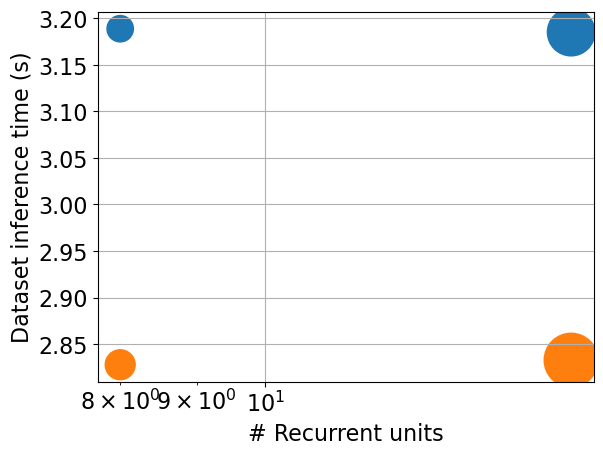

In [19]:
plt.scatter(x=units, y=gru_inference_times, marker='o', s=1.5e3*gru_norm_parameters_count)
plt.scatter(x=units, y=lstm_inference_times, marker='o', s=1.5e3*lstm_norm_parameters_count)

plt.xscale('log')
plt.grid()
plt.ylabel('Dataset inference time (s)')
plt.xlabel('# Recurrent units')
plt.show()

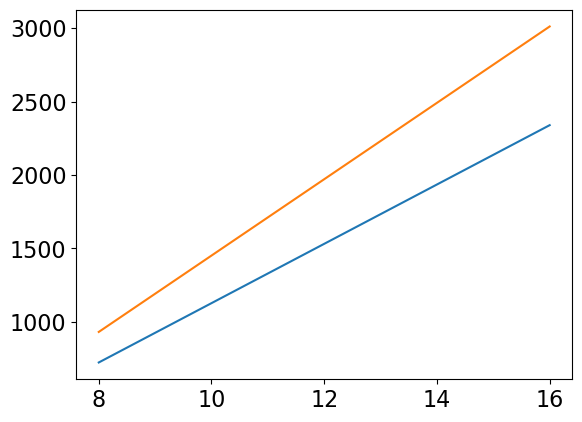

In [20]:
plt.plot(units, gru_parameters_count)
plt.plot(units, lstm_parameters_count)

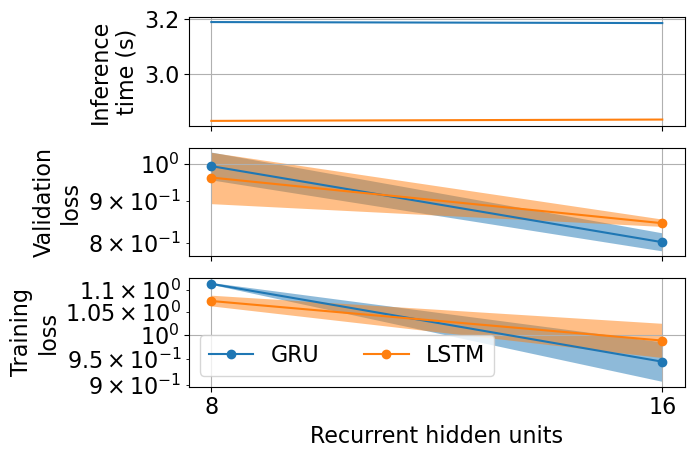

In [21]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, sharex=True)

# dataset inference time
ax1.plot(units, gru_inference_times)
ax1.plot(units, lstm_inference_times)
ax1.set_ylabel('Inference\ntime (s)')
ax1.grid()

# vl loss
ax2.plot(units, gru_vl_losses, 'o-')
ax2.plot(units, lstm_vl_losses, 'o-')

ax2.fill_between(x=units, y1=gru_vl_losses - gru_vl_std_losses, y2=gru_vl_losses + gru_vl_std_losses, alpha=0.5)
ax2.fill_between(x=units, y1=lstm_vl_losses - lstm_vl_std_losses, y2=lstm_vl_losses + lstm_vl_std_losses, alpha=0.5)
ax2.set_yscale('log')
ax2.set_ylabel('Validation\nloss')
ax2.grid()

# tr loss
ax3.plot(units, gru_tr_losses, 'o-', label='GRU')
ax3.plot(units, lstm_tr_losses, 'o-', label='LSTM')

ax3.fill_between(x=units, y1=gru_tr_losses - gru_tr_std_losses, y2=gru_tr_losses + gru_tr_std_losses, alpha=0.5)
ax3.fill_between(x=units, y1=lstm_tr_losses - lstm_tr_std_losses, y2=lstm_tr_losses + lstm_tr_std_losses, alpha=0.5)
ax3.set_yscale('log')
ax3.set_ylabel('Training\nloss')
ax3.set_xlabel('Recurrent hidden units')
ax3.legend(loc='best', ncols=2)
ax3.set_xticks(units)
ax3.grid()